# Работа с данными и коэффициент корреляции

**Дисциплина:** Введение в анализ больших данных

На этом занятии:
- генерация выборок и базовые статистики;
- эмпирическая функция распределения (ECDF);
- корреляция Пирсона, Спирмена, Кендалла и проверка значимости;
- стандартизация и логарифмирование;
- точечные диаграммы и группировка на реальном датасете.




## 0. Импорт библиотек


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.distributions.empirical_distribution import ECDF

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")
np.random.seed(1337)


---
## 1. Нормальная выборка

Генерация: `stats.norm.rvs(loc=μ, scale=σ, size=n)`.

**Демо:** «рост» $N(170,\,8)$, $n = 80$.


In [15]:
x1 = stats.norm.rvs(loc=3, scale=2, size=100)

print("Первые 8:", x1[:8].round(2))
print(f"среднее mean                = {x1.mean():.3f}")
print(f"Стандартное отклонение sd   = {x1.std(ddof=1):.3f}")
print(f"дисперсия var               = {x1.var(ddof=1):.3f}")


Первые 8: [4.6  3.57 1.75 4.74 3.49 2.66 0.91 1.3 ]
среднее mean                = 3.072
Стандартное отклонение sd   = 1.870
дисперсия var               = 3.496


---
## 2. Дискретная выборка (биномиальная)

`stats.binom.rvs(n=trials, p=prob, size=m)`.

**Демо:** число успехов в 12 испытаниях, $p=0.4$, объём 200.


In [16]:
x2 = stats.binom.rvs(n=10, p=0.5, size=500)

print("Первые 15:", x2[:15])
print(f"среднее mean                = {x2.mean():.3f}")
print(f"Стандартное отклонение sd   = {x2.std(ddof=1):.3f}")
print(f"дисперсия var               = {x2.var(ddof=1):.3f}")
print('Series: ')
print(pd.Series(x2).describe())


Первые 15: [4 5 6 5 6 1 5 4 2 2 4 5 6 7 3]
среднее mean                = 4.954
Стандартное отклонение sd   = 1.486
дисперсия var               = 2.208
Series: 
count    500.000000
mean       4.954000
std        1.486035
min        0.000000
25%        4.000000
50%        5.000000
75%        6.000000
max        9.000000
dtype: float64


---
## 3. Эмпирическая функция распределения (ECDF)

ECDF — доля наблюдений ≤ x.  
Строится через `ECDF` (statsmodels) или `sns.ecdfplot`.


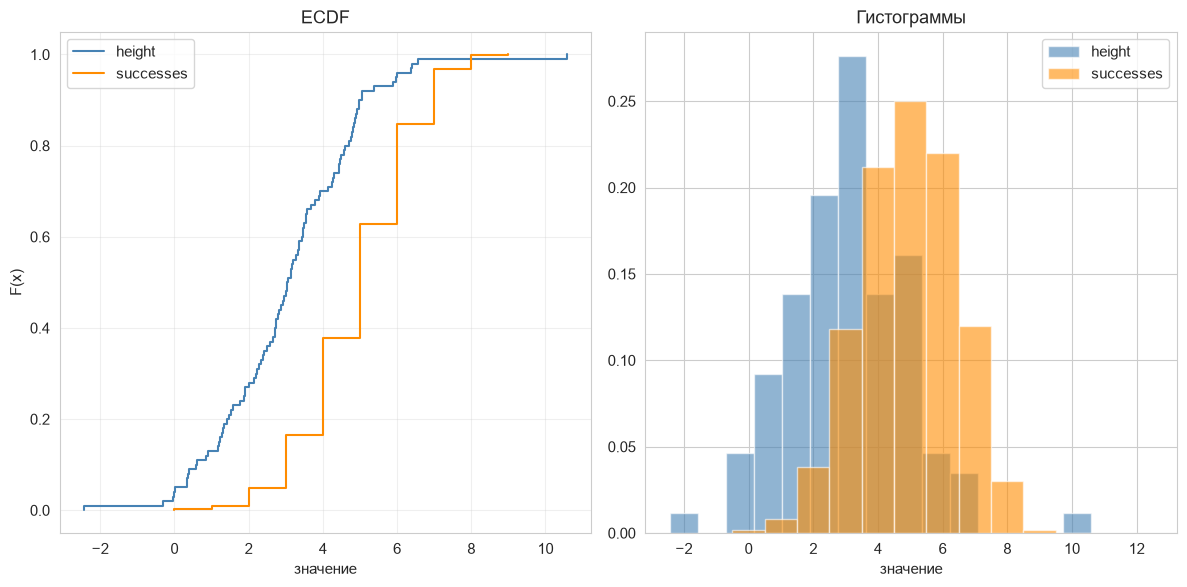

In [19]:
ecdf_h = ECDF(x1)
ecdf_s = ECDF(x2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].step(ecdf_h.x, ecdf_h.y, where="post", color="steelblue", label="height")
axes[0].step(ecdf_s.x, ecdf_s.y, where="post", color="darkorange", label="successes")
axes[0].set_title("ECDF")
axes[0].set_xlabel("значение")
axes[0].set_ylabel("F(x)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(x1, bins=15, density=True, alpha=0.6, color="steelblue", label="height")
axes[1].hist(x2, bins=range(0, 14), density=True, alpha=0.6,
             color="darkorange", align="left", label="successes")
axes[1].set_title("Гистограммы")
axes[1].set_xlabel("значение")
axes[1].legend()

plt.tight_layout()
plt.show()


In [23]:
x2_100 = x2[-100:]

print("Длина x2_100:", len(x2_100))
print("x2_100 (первые 10):", x2_100[:10])

Длина x2_100: 100
x2_100 (первые 10): [5 6 3 5 3 8 3 5 2 5]


---
## 4. Корреляция: Пирсон, Спирмен, Кендалл

| Метод | Когда уместен |
|-------|----------------|
| **Пирсон** | линейная связь, количественные ≈ нормальные |
| **Спирмен** | монотонная связь, ранги / порядковые |
| **Кендалл** | порядковые шкалы, мало совпадающих рангов |

|r|: 0–0.1 нет связи; 0.1–0.5 слабая; 0.5–0.7 умеренная; 0.7–1 сильная.

H0 в тесте: «связи нет» (ρ = 0). При p < 0.05 обычно отвергают H0.


In [24]:
np.random.seed(1337)
x = stats.norm.rvs(0, 1, size=120)
y = 0.6 * x + stats.norm.rvs(0, 0.8, size=120)

r_p, p_p = stats.pearsonr(x1, x2_100)
r_s, p_s = stats.spearmanr(x1, x2_100)
r_k, p_k = stats.kendalltau(x1, x2_100)

print(f"Пирсон  : r = {r_p:+.4f}, p = {p_p:.4g}")
print(f"Спирмен : r = {r_s:+.4f}, p = {p_s:.4g}")
print(f"Кендалл : r = {r_k:+.4f}, p = {p_k:.4g}")

print("\n--- Интерпретация ---")
def interpret(r, p):
    mod = abs(r)
    if mod < 0.1:   strength = "связи нет"
    elif mod < 0.5: strength = "слабая связь"
    elif mod < 0.7: strength = "умеренная связь"
    else:           strength = "сильная связь"
    sig = "значима" if p < 0.05 else "не значима"
    direction = "прямая" if r > 0 else "обратная"
    return f"{strength}, {direction}, {sig} (p={p:.4g})"

print("Пирсон :", interpret(r_p, p_p))
print("Спирмен:", interpret(r_s, p_s))
print("Кендалл:", interpret(r_k, p_k))


Пирсон  : r = -0.0590, p = 0.5599
Спирмен : r = -0.0522, p = 0.6059
Кендалл : r = -0.0375, p = 0.6078

--- Интерпретация ---
Пирсон : связи нет, обратная, не значима (p=0.5599)
Спирмен: связи нет, обратная, не значима (p=0.6059)
Кендалл: связи нет, обратная, не значима (p=0.6078)


| Метод | Когда использовать |
|---|---|
| **Пирсон** | Данные непрерывные, близки к нормальному распределению, ищем **линейную** связь |
| **Спирмен** | Данные не нормальные, есть выбросы, или работаем с **рангами** (места, оценки) |
| **Кендалл** | Мало данных или много одинаковых значений (связанные ранги) |

> 💡 Для одних и тех же данных: |r_Спирмена| ≥ |r_Кендалла|, но p-value у них обычно близки.





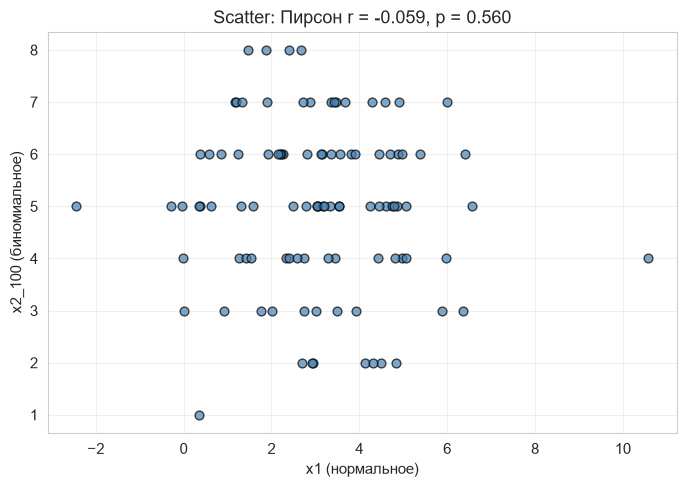

In [26]:
plt.figure(figsize=(7, 5))
plt.scatter(x1, x2_100, alpha=0.7, edgecolors="black", s=40, color="steelblue")
plt.xlabel("x1 (нормальное)")
plt.ylabel("x2_100 (биномиальное)")
plt.title(f"Scatter: Пирсон r = {r_p:.3f}, p = {p_p:.3f}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [27]:
x3 = np.column_stack([x1, x2_100])
print("Форма x3:", x3.shape)
print("Первые 3 строки:\n", x3[:3])

Форма x3: (100, 2)
Первые 3 строки:
 [[4.60171877 5.        ]
 [3.56955106 6.        ]
 [1.75432998 3.        ]]


In [28]:
x4 = x2.reshape(100, 5)   # 500 / 5 = 100 строк, 5 столбцов
print("Форма x4:", x4.shape)
print("Первые 3 строки:\n", x4[:3])

Форма x4: (100, 5)
Первые 3 строки:
 [[4 5 6 5 6]
 [1 5 4 2 2]
 [4 5 6 7 3]]


---
## 5. Матрица и корреляции между столбцами

`np.column_stack` / `reshape` + `np.corrcoef` или `DataFrame.corr()`.


Корреляции 4 столбцов:
 [[ 1.    -0.02  -0.018  0.074  0.153]
 [-0.02   1.     0.065  0.112 -0.08 ]
 [-0.018  0.065  1.    -0.105 -0.038]
 [ 0.074  0.112 -0.105  1.    -0.045]
 [ 0.153 -0.08  -0.038 -0.045  1.   ]]


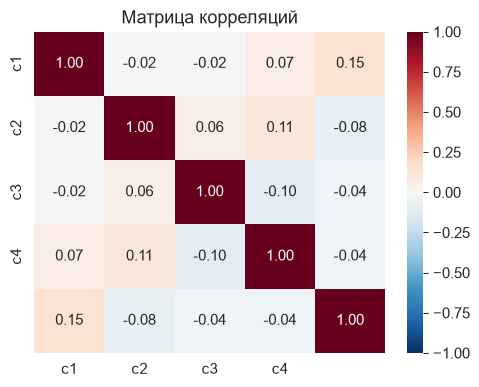

In [29]:
corr4 = np.corrcoef(x4, rowvar=False)
print("Корреляции 4 столбцов:\n", np.round(corr4, 3))

plt.figure(figsize=(5, 4))
sns.heatmap(corr4, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0,
            xticklabels=[f"c{i+1}" for i in range(4)],
            yticklabels=[f"c{i+1}" for i in range(4)])
plt.title("Матрица корреляций")
plt.tight_layout()
plt.show()


---
## 6. Стандартизация

$$
z = \frac{x - \bar{x}}{s}
$$

После преобразования mean ≈ 0, sd ≈ 1.


In [31]:
z_manual = (x2 - x2.mean()) / x2.std(ddof=1)
z_sklearn = (x2 - np.mean(x2)) / np.std(x2, ddof=1)

print("Первые 5 (вручную):", z_manual[:5].round(4))
print("Первые 5 (sklearn):", z_sklearn[:5].round(4))
print("Совпадают?", np.allclose(z_manual, z_sklearn))
print(f"mean(z) ≈ {z_manual.mean():.2e}, sd(z) ≈ {z_manual.std(ddof=1):.4f}")


Первые 5 (вручную): [-0.642   0.031   0.7039  0.031   0.7039]
Первые 5 (sklearn): [-0.642   0.031   0.7039  0.031   0.7039]
Совпадают? True
mean(z) ≈ 1.76e-16, sd(z) ≈ 1.0000


---
## 7. Логарифмирование

Полезно при правосторонней асимметрии. Берите только положительные значения.


In [32]:
positive = x1[x1 > 0]
log_h = np.round(np.log(positive), 3)
print("log(height), первые 8:", log_h[:8])


log(height), первые 8: [ 1.526  1.272  0.562  1.557  1.249  0.98  -0.09   0.266]


---
## 8. Пример на датасете **penguins**

Возьмём датасет пингвинов: масса тела, вид, остров.


In [33]:
# penguins = sns.load_dataset("penguins").dropna()
# print(penguins.head())
# print(penguins.columns.tolist())


  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
4       3450.0  Female  
5       3650.0    Male  
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


### Dotchart: диаграмма по mtcars


Колонки: ['rownames', 'mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear', 'carb']
Первые 5 строк:


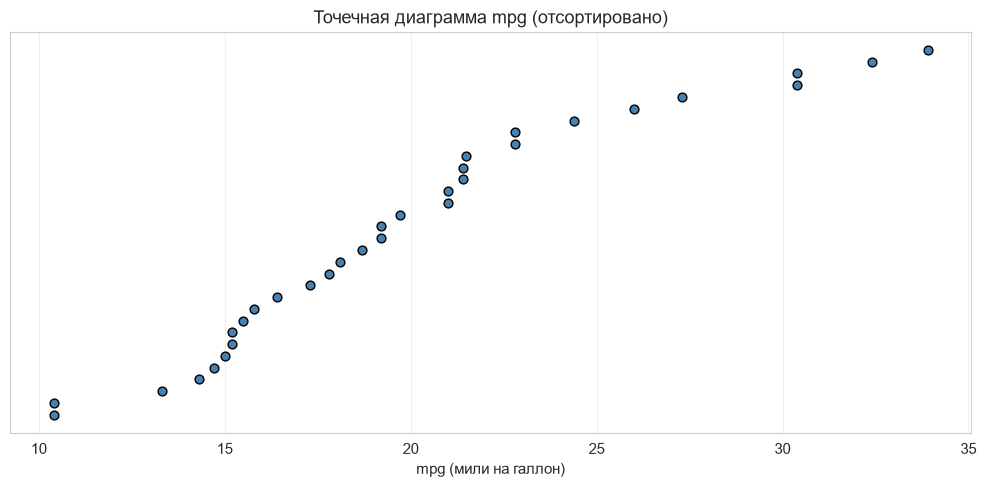

In [50]:
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/mtcars.csv"
mtcars = pd.read_csv(url)
print("Колонки:", mtcars.columns.tolist())
print("Первые 5 строк:")
mtcars.head()

# Точечная диаграмма mpg (dotchart-стиль)
mpg_sorted = np.sort(mtcars["mpg"].values)
plt.figure(figsize=(10, 5))
plt.scatter(mpg_sorted, range(len(mpg_sorted)), color="steelblue",
            s=40, edgecolors="black")
plt.yticks([])
plt.xlabel("mpg (мили на галлон)")
plt.title("Точечная диаграмма mpg (отсортировано)")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Описательные статистики по группам


In [44]:
print("=== mpg: вся выборка ===")
print(mtcars["mpg"].describe())

print("\n=== mpg по категориям vs ===")
print(mtcars.groupby("vs")["mpg"].describe().round(2))


=== mpg: вся выборка ===
count    32.000000
mean     20.090625
std       6.026948
min      10.400000
25%      15.425000
50%      19.200000
75%      22.800000
max      33.900000
Name: mpg, dtype: float64

=== mpg по категориям vs ===
    count   mean   std   min    25%    50%    75%   max
vs                                                     
0    18.0  16.62  3.86  10.4  14.77  15.65  19.08  26.0
1    14.0  24.56  5.38  17.8  21.40  22.80  29.62  33.9


### Гистограммы и ECDF (вся выборка и по группам)


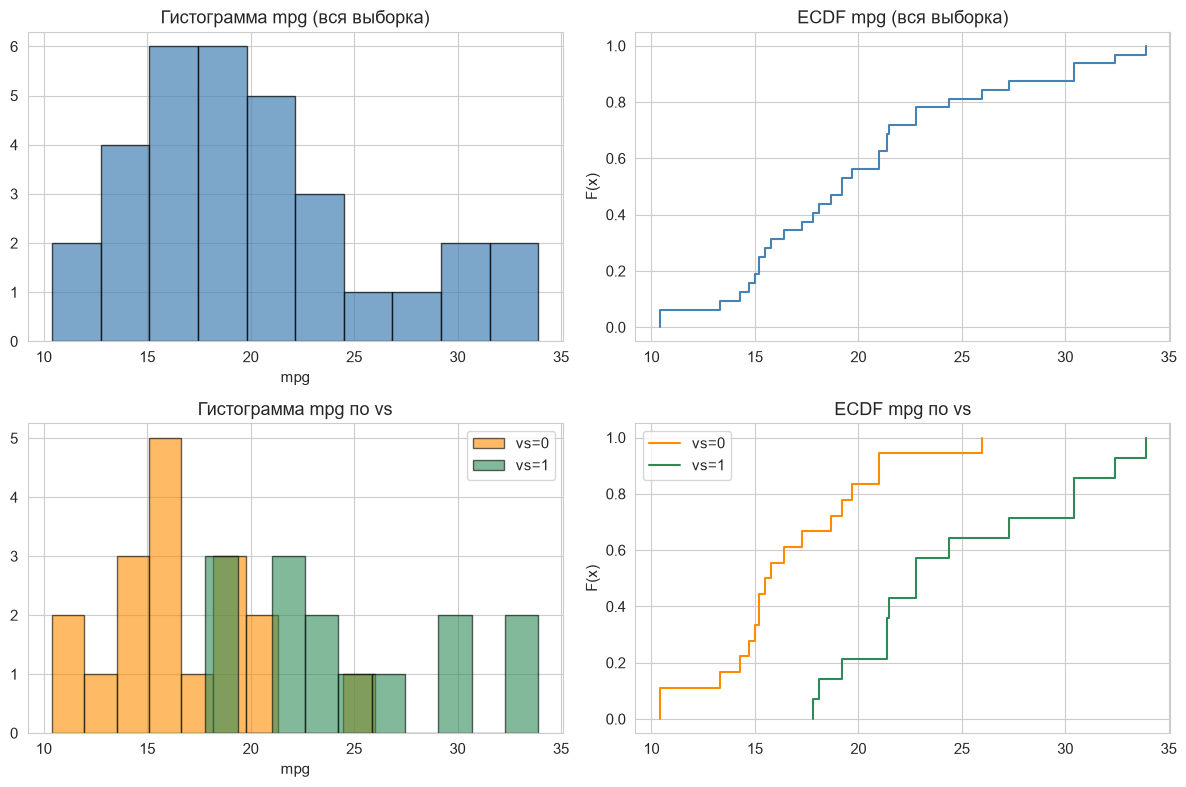

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Вся выборка: гистограмма
axes[0, 0].hist(mtcars["mpg"], bins=10, color="steelblue", edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Гистограмма mpg (вся выборка)")
axes[0, 0].set_xlabel("mpg")

# Вся выборка: ECDF
ec = ECDF(mtcars["mpg"])
axes[0, 1].step(ec.x, ec.y, where="post", color="steelblue")
axes[0, 1].set_title("ECDF mpg (вся выборка)")
axes[0, 1].set_ylabel("F(x)")

# По группам vs: гистограмма
palette = {0: "darkorange", 1: "seagreen"}
for v, col in palette.items():
    sub = mtcars.loc[mtcars["vs"] == v, "mpg"]
    axes[1, 0].hist(sub, bins=10, alpha=0.6, label=f"vs={v}", color=col, edgecolor="black")
axes[1, 0].set_title("Гистограмма mpg по vs")
axes[1, 0].set_xlabel("mpg")
axes[1, 0].legend()

# По группам vs: ECDF
for v, col in palette.items():
    sub = mtcars.loc[mtcars["vs"] == v, "mpg"]
    ec_s = ECDF(sub)
    axes[1, 1].step(ec_s.x, ec_s.y, where="post", label=f"vs={v}", color=col)
axes[1, 1].set_title("ECDF mpg по vs")
axes[1, 1].set_ylabel("F(x)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

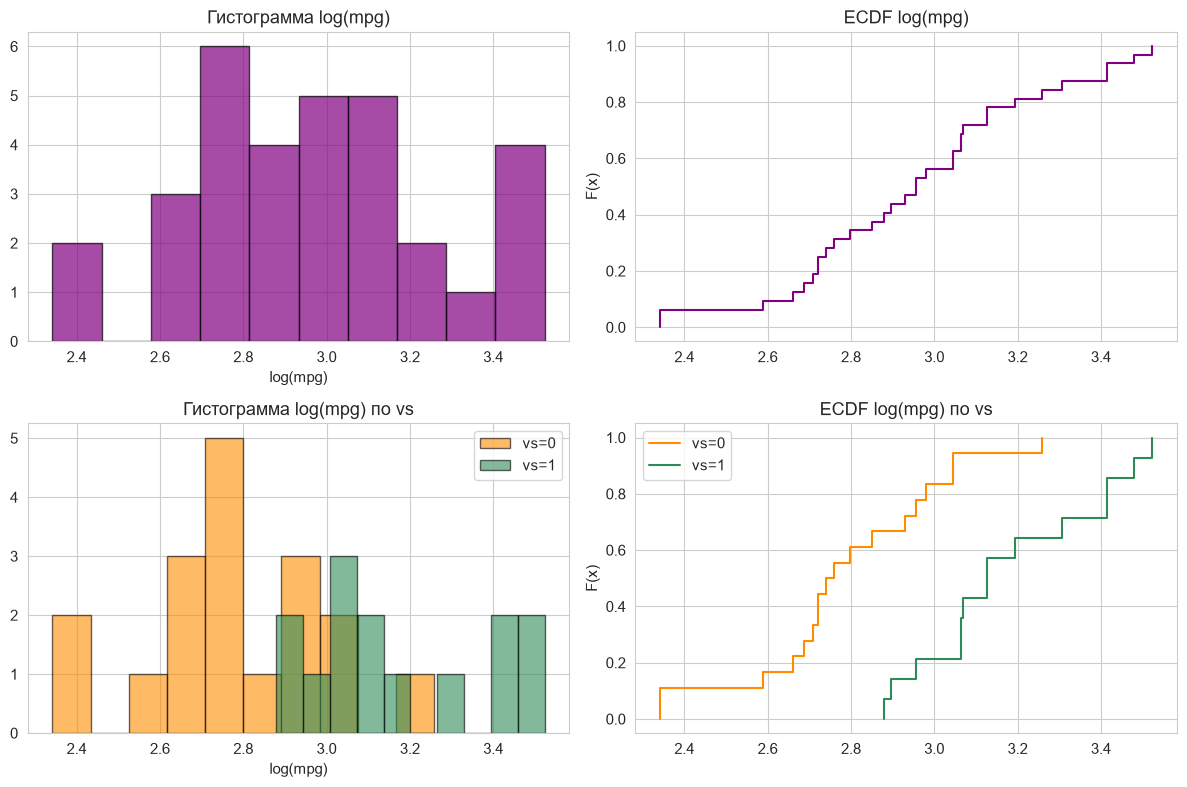


--- Сравнение ---
Исходный mpg:   skewness = 0.672
Логарифм mpg:   skewness = -0.024


In [40]:
mtcars["log_mpg"] = np.log(mtcars["mpg"])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# log(mpg) вся выборка
axes[0, 0].hist(mtcars["log_mpg"], bins=10, color="purple", edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Гистограмма log(mpg)")
axes[0, 0].set_xlabel("log(mpg)")

ec_log = ECDF(mtcars["log_mpg"])
axes[0, 1].step(ec_log.x, ec_log.y, where="post", color="purple")
axes[0, 1].set_title("ECDF log(mpg)")
axes[0, 1].set_ylabel("F(x)")

# log(mpg) по vs
for v, col in palette.items():
    sub = mtcars.loc[mtcars["vs"] == v, "log_mpg"]
    axes[1, 0].hist(sub, bins=10, alpha=0.6, label=f"vs={v}", color=col, edgecolor="black")
axes[1, 0].set_title("Гистограмма log(mpg) по vs")
axes[1, 0].set_xlabel("log(mpg)")
axes[1, 0].legend()

for v, col in palette.items():
    sub = mtcars.loc[mtcars["vs"] == v, "log_mpg"]
    ec_s = ECDF(sub)
    axes[1, 1].step(ec_s.x, ec_s.y, where="post", label=f"vs={v}", color=col)
axes[1, 1].set_title("ECDF log(mpg) по vs")
axes[1, 1].set_ylabel("F(x)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n--- Сравнение ---")
print(f"Исходный mpg:   skewness = {mtcars['mpg'].skew():.3f}")
print(f"Логарифм mpg:   skewness = {mtcars['log_mpg'].skew():.3f}")


---
## Шпаргалка по методам (Python)

| Задача | Код Python | Зачем это нужно |
|---|---|---|
| Нормальная выборка | `stats.norm.rvs(loc=μ, scale=σ, size=n)` | Генерация непрерывных данных (рост, вес, ошибки измерений) |
| Биномиальная выборка | `stats.binom.rvs(n=trials, p=prob, size=m)` | Моделирование «числа успехов» (орлы при бросках монеты) |
| Среднее значение | `x.mean()` | «Центр» данных |
| Стандартное отклонение | `x.std(ddof=1)` | Разброс данных вокруг среднего (несмещённая оценка) |
| Дисперсия | `x.var(ddof=1)` | Квадрат стд. отклонения |
| Описательные статистики | `pd.Series(x).describe()` | Быстрый обзор: min, max, квантили, mean, std |
| Эмпирическая функция распределения | `ECDF(x)` (statsmodels) | Точная ступенчатая функция F(x) = P(X ≤ x) |
| Корреляция Пирсона | `stats.pearsonr(x, y)` → `(r, p)` | Линейная связь между нормальными величинами |
| Корреляция Спирмена | `stats.spearmanr(x, y)` | Монотонная связь (ранги), устойчива к выбросам |
| Корреляция Кендалла | `stats.kendalltau(x, y)` | Ранговая связь, консервативнее Спирмена |
| Матрица корреляций | `np.corrcoef(M, rowvar=False)` | Попарные корреляции между столбцами матрицы |
| Объединение векторов в матрицу | `np.column_stack([x1, x2])` | Склеить два вектора в таблицу (столбцы = переменные) |
| Разбиение вектора в матрицу | `x.reshape(n_rows, n_cols)` | Превратить длинный вектор в таблицу |
| Стандартизация вручную | `(x - x.mean()) / x.std(ddof=1)` | Привести к масштабу mean=0, std=1 |
| Стандартизация через sklearn | `StandardScaler().fit_transform(x.reshape(-1,1))` | То же самое, но объектно-ориентированно |
| Логарифмирование | `np.log(x)` | Убирает правостороннюю асимметрию |
| Округление | `np.round(x, 3)` | Аккуратный вывод с N знаками после запятой |
| Загрузка датасета | `pd.read_csv(url)` | Чтение таблицы по ссылке |
| Группировка по категории | `df.groupby("col")["val"].describe()` | Статистики отдельно для каждой группы |
| Scatter-график | `plt.scatter(x, y)` | Визуализация связи двух переменных |
| Гистограмма | `plt.hist(x, bins=15, density=True)` | Распределение одной переменной |
| Точечная диаграмма (dotchart) | `plt.scatter(sorted_x, range(len(x)))` | Показать все значения по порядку |
| Тепловая карта корреляций | `sns.heatmap(corr, annot=True, cmap="RdBu_r")` | Наглядная матрица попарных связей |
